In [1]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('diabetic_data.csv')

# Display basic information
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 101,766 rows × 50 columns


In [5]:
sample = df.head()
print ("First 5 rows")
print (sample)

First 5 rows
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

In [9]:
columnnames= df.columns
print ("Column names")
print (columnnames)



Column names
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


In [10]:
data_types = df.info()
print ("Data types")
print (data_types)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [11]:
null_values = df.isnull().sum()
print ("Null vlaues")
print (null_values)



Null vlaues
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
ac

In [12]:
readmitted_data = df['readmitted'].value_counts()
print (readmitted_data)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


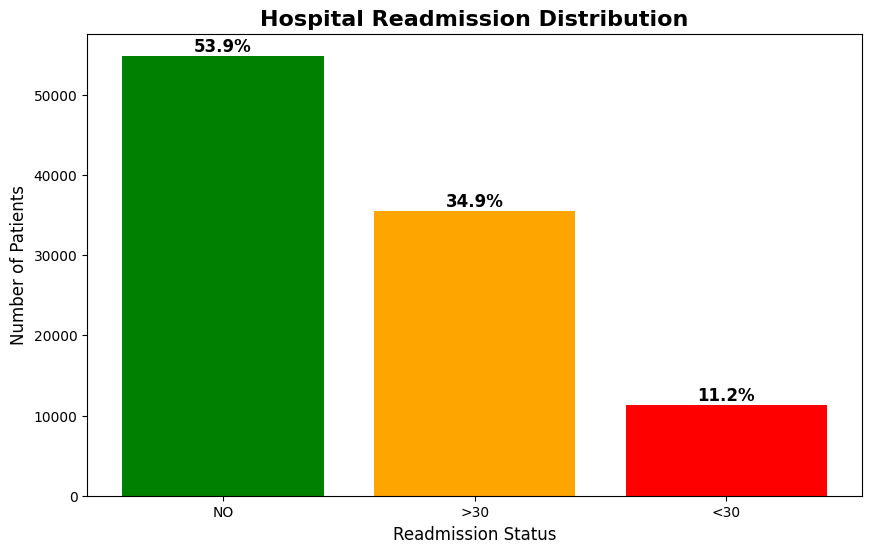

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


In [16]:
# Visualize readmission distribution

# Bar chart with percentages
plt.figure(figsize=(10, 6))
counts = df['readmitted'].value_counts()
bars = plt.bar(counts.index, counts.values, color=['green', 'orange', 'red'])

# Add percentage labels on top of bars
total = len(df)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{percentage:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Hospital Readmission Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.show()
readmission_percentages = df['readmitted'].value_counts(normalize=True) * 100
print (readmission_percentages)

<Figure size 1200x600 with 0 Axes>

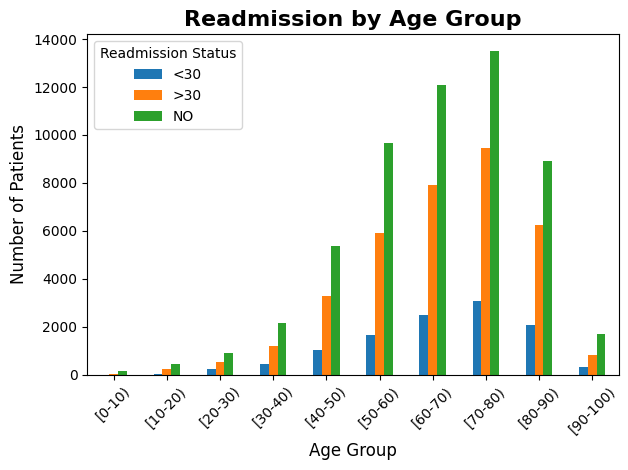

In [17]:
# Age distribution by readmission status
plt.figure(figsize=(12, 6))
df.groupby(['age', 'readmitted']).size().unstack().plot(kind='bar', stacked=False)
plt.title('Readmission by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Readmission Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

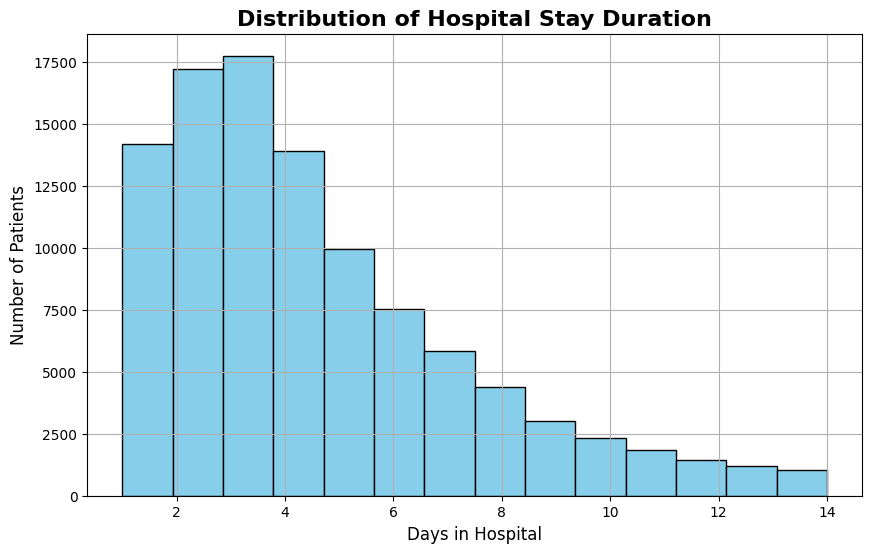

In [18]:
# Time in hospital distribution
plt.figure(figsize=(10, 6))
df['time_in_hospital'].hist(bins=14, edgecolor='black', color='skyblue')
plt.title('Distribution of Hospital Stay Duration', fontsize=16, fontweight='bold')
plt.xlabel('Days in Hospital', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.show()

<Figure size 1000x600 with 0 Axes>

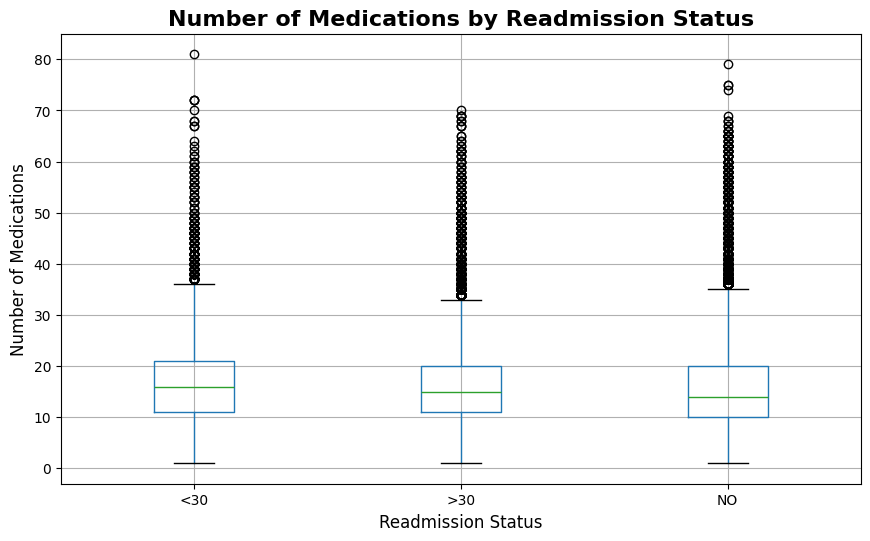

In [19]:
# Medications by readmission status
plt.figure(figsize=(10, 6))
df.boxplot(column='num_medications', by='readmitted', figsize=(10, 6))
plt.title('Number of Medications by Readmission Status', fontsize=16, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Number of Medications', fontsize=12)
plt.show()

In [22]:
# Calculate average emergency visits by readmission status
emergency_avg = df.groupby('readmitted')['number_emergency'].mean()

print("Average Emergency Visits in Past Year:")
print(emergency_avg)
print()

# Calculate average inpatient visits by readmission status
inpatient_avg = df.groupby('readmitted')['number_inpatient'].mean()

print("Average Inpatient Visits in Past Year:")
print(inpatient_avg)

Average Emergency Visits in Past Year:
readmitted
<30    0.357313
>30    0.283669
NO     0.109216
Name: number_emergency, dtype: float64

Average Inpatient Visits in Past Year:
readmitted
<30    1.224003
>30    0.838993
NO     0.381963
Name: number_inpatient, dtype: float64


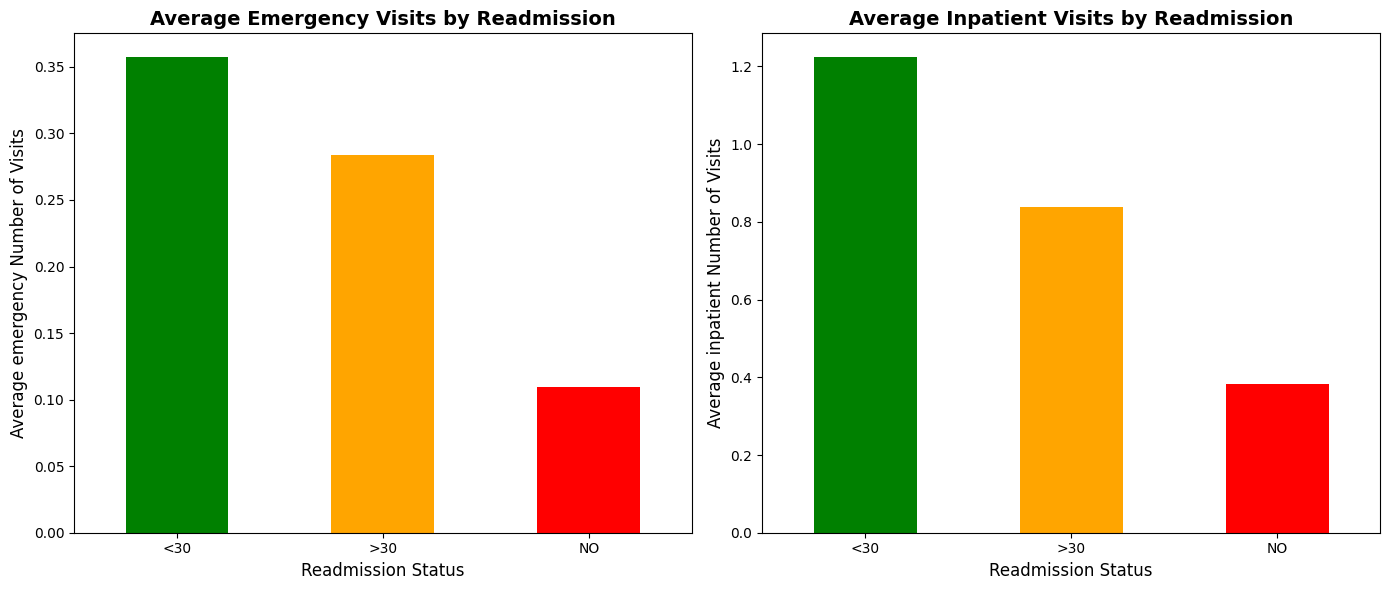

In [26]:
# Create a comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Emergency visits
emergency_avg.plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('Average Emergency Visits by Readmission', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Readmission Status', fontsize=12)
axes[0].set_ylabel('Average emergency Number of Visits', fontsize=12)
axes[0].set_xticklabels(emergency_avg.index, rotation=0)

# Inpatient visits
inpatient_avg.plot(kind='bar', ax=axes[1], color=['green', 'orange', 'red'])
axes[1].set_title('Average Inpatient Visits by Readmission', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Readmission Status', fontsize=12)
axes[1].set_ylabel('Average inpatient Number of Visits', fontsize=12)
axes[1].set_xticklabels(inpatient_avg.index, rotation=0)

plt.tight_layout()
plt.show()


Average Number of Lab Procedures:
readmitted
<30    44.226028
>30    43.836601
NO     42.381598
Name: num_lab_procedures, dtype: float64



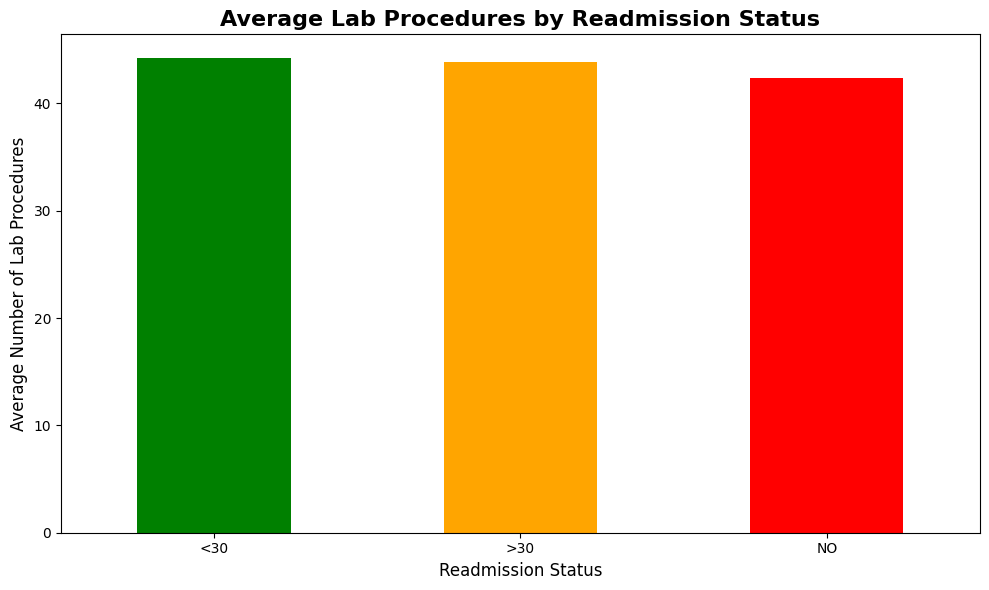

In [27]:
# Calculate average lab procedures by readmission status
lab_avg = df.groupby('readmitted')['num_lab_procedures'].mean()

print("Average Number of Lab Procedures:")
print(lab_avg)
print()

# Visualize
plt.figure(figsize=(10, 6))
lab_avg.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Lab Procedures by Readmission Status', fontsize=16, fontweight='bold')
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Average Number of Lab Procedures', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Number of Procedures:
readmitted
<30    1.280884
>30    1.249599
NO     1.410305
Name: num_procedures, dtype: float64



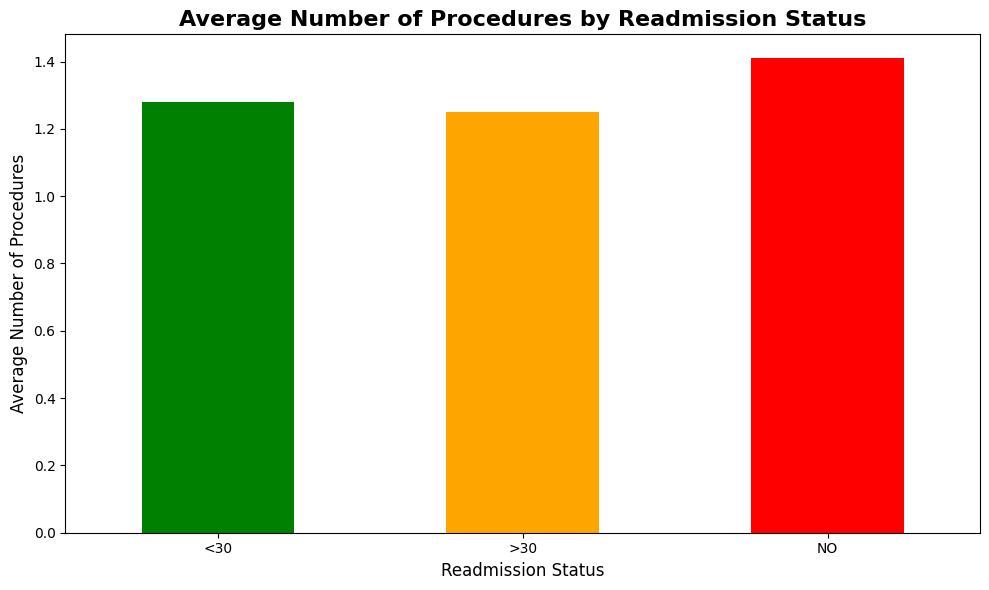

In [28]:
# Calculate average procedures by readmission status
proc_avg = df.groupby('readmitted')['num_procedures'].mean()

print("Average Number of Procedures:")
print(proc_avg)
print()

# Visualize
plt.figure(figsize=(10, 6))
proc_avg.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Number of Procedures by Readmission Status', fontsize=16, fontweight='bold')
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Average Number of Procedures', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Number of Diagnoses:
readmitted
<30    7.692789
>30    7.646898
NO     7.221366
Name: number_diagnoses, dtype: float64



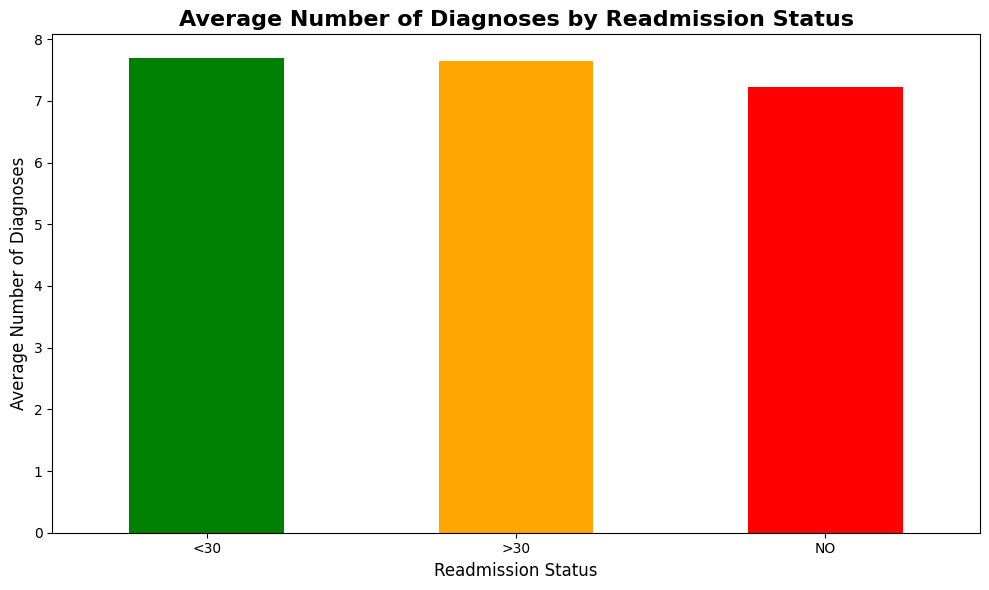

In [29]:
# Calculate average number of diagnoses by readmission status
diag_avg = df.groupby('readmitted')['number_diagnoses'].mean()

print("Average Number of Diagnoses:")
print(diag_avg)
print()

# Visualize
plt.figure(figsize=(10, 6))
diag_avg.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Number of Diagnoses by Readmission Status', fontsize=16, fontweight='bold')
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Average Number of Diagnoses', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Analysis Summary: Hospital Readmission Patterns

## 🎯 Objective
Identify key factors that predict hospital readmission within 30 days for diabetic patients.

## 📊 Dataset Overview
- **Total Patients:** 101766 patients
- **Readmission Rate (<30 days):** 11.2%
- **Time Period:** 1999-2008
- **Hospitals:** 130 US hospitals

## 🔍 Key Findings

### 1. Class Imbalance
- Only 11.2% of patients are readmitted within 30 days
- This is a highly imbalanced dataset - important for future modeling

### 2. Strong Predictors of 30-Day Readmission

#### Age (50-80 years)
- **Finding:** Patients aged 50-80 have the highest readmission rates
- **Why it matters:** This age group may need targeted interventions
- **Note:** Drop-off in 80+ likely due to mortality or nursing home placement

#### Number of Medications
- **Finding:** Readmitted patients take MORE medications (median: 15 vs 13)
- **Why it matters:** Medication complexity increases risk of errors and side effects
- **Implication:** Better medication management and patient education needed

#### Prior Emergency Visits
- **Finding:** Patients readmitted within 30 days had MORE emergency visits in the past year
- **Why it matters:** History of frequent ER use indicates chronic health issues
- **Pattern:** "Frequent flyers" are at higher risk

#### Prior Inpatient Visits
- **Finding:** Patients readmitted within 30 days had MORE previous hospitalizations
- **Why it matters:** Past hospital use predicts future hospital use
- **Pattern:** Chronically ill patients need better care coordination

### 3. Weak/No Predictors
- Number of lab procedures - no clear pattern
- Number of procedures - no clear pattern  
- Number of diagnoses - no clear pattern

## 💡 Recommendations for Hospitals

### High-Risk Patient Profile
Target interventions for patients with:
- ✅ Age 50-80 years
- ✅ 15+ medications
- ✅ History of frequent ER visits
- ✅ Previous hospitalizations in past year

### Suggested Interventions
1. **Medication Review:** Pharmacist consultation before discharge for patients on 15+ medications
2. **Follow-up Calls:** Proactive outreach within 7 days of discharge for high-risk patients
3. **Care Coordination:** Assign care managers to "frequent flyers"
4. **Patient Education:** Focus on medication management for older adults
5. **Post-discharge Support:** Home visits or telehealth check-ins for 50-80 age group

## 🚀 Next Steps
1. Clean and prepare data for modeling
2. Build predictive model using identified risk factors
3. Validate model performance
4. Create risk score calculator for clinical use